<a href="https://colab.research.google.com/github/DinRazar/neural_networks/blob/main/%D0%A0%D0%B0%D0%B1%D0%BE%D1%82%D0%B0_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Задание №5. Формирование календарного плана проекта и управление рисками**



## **Введение**


После определения концептуальных основ проекта, анализа существующих решений, формирования структуры работ и разработки спецификации требований Вы получили чёткое представление о содержании и требованиях к системе. Теперь важно перейти к планированию её реализации с применением инструментов проектного управления.

## **Формулировка задания**


В рамках данного задания Вам необходимо разработать систему управления для вашего дипломного проекта, включающую планирование, анализ рисков и определение основных контрольных точек. Данная работа поможет вам структурировать процесс выполнения дипломного проекта и обеспечить его успешную реализацию в установленные сроки.


### **Необходимо выполнить:**





1. **Разработать календарный план проекта в формате диаграммы Ганта**:
   - Определите все основные этапы и задачи вашего дипломного проекта
   - Установите реалистичные сроки выполнения каждой задачи
   - Отобразите зависимости между задачами

2. **Выполнить анализ и разработать систему управления рисками проекта**:
   - Определите не менее 3-5 потенциальных рисков, специфичных для вашего проекта
   - Оцените вероятность возникновения и степень влияния каждого риска
   - Разработайте конкретные стратегии реагирования на каждый риск
   - Представьте результаты в виде структурированной таблицы

3. **Определить основные контрольные точки проекта**:
   - Выделите 3-5 важнейших контрольных точек процесса разработки
   - Для каждой контрольной точки сформулируйте чёткие, измеримые критерии достижения
   - Установите конкретные даты для контрольных точек
   - Укажите ответственных (если проект групповой) и необходимые ресурсы

4. **Подготовить пояснительную записку**:
   - Обоснуйте выбранную структуру работ календарного плана
   - Поясните методологию анализа рисков и принципы определения контрольных точек
   - Опишите взаимосвязь между всеми компонентами системы

## **Требования к выполнению задания:**



1. Все компоненты задания должны соответствовать теме вашего дипломного проекта
2. Календарный план должен быть реалистичным и выполнимым в рамках дипломного проектирования
3. Риски должны быть специфичными для вашего проекта, а не общими для любых IT-проектов
4. Контрольные точки должны иметь четкие, измеримые критерии достижения
5. Все элементы должны быть логически связаны между собой

## **Что должно получиться в итоге:**







1. Диаграмма Ганта
2. Таблица рисков проекта
3. Таблица контрольных точек
4. Пояснительная записка с обоснованием принятых решений

# **Пример выполненного задания №4: Формирование календарного плана проекта и управление рисками**



## **Тема дипломного проекта: "Разработка мобильного приложения классификации болезней кожи по фото"**



### **1. Календарный план проекта (диаграмма Ганта)**



#### **Функция Python для построения диаграммы Ганта:**

In [ ]:
def create_gantt_chart(tasks, title="Диаграмма Ганта", save_path="gantt_chart.png", figsize=(16, 8)):
    """
    Создает и сохраняет диаграмму Ганта в виде таблицы на основе предоставленных данных о задачах.

    Параметры:
    ----------
    tasks : list of dict
        Список словарей, каждый из которых содержит информацию о задаче в формате:
        {"Task": "Название задачи", "Start": "YYYY-MM-DD", "End": "YYYY-MM-DD", "Group": "Группа задачи"}
    title : str, optional
        Заголовок диаграммы
    save_path : str, optional
        Путь для сохранения изображения
    figsize : tuple, optional
        Размер изображения (ширина, высота) в дюймах

    Возвращает:
    -----------
    None (сохраняет изображение и отображает его)
    """
    import pandas as pd
    import numpy as np
    import matplotlib.pyplot as plt
    import seaborn as sns
    from datetime import datetime, timedelta

    # Создание DataFrame и преобразование дат
    df = pd.DataFrame(tasks)
    df['Start'] = pd.to_datetime(df['Start'])
    df['End'] = pd.to_datetime(df['End'])

    # Определение временного диапазона проекта
    project_start = df['Start'].min().date()
    project_end = df['End'].max().date()
    project_duration = (project_end - project_start).days + 1

    # Создание всех дат проекта
    all_dates = [project_start + timedelta(days=i) for i in range(project_duration)]
    date_labels = [date.strftime('%d-%m') for date in all_dates]

    # Создание длинного формата данных для heatmap
    gantt_data = []
    for i, task in enumerate(df.itertuples()):
        task_start = task.Start.date()
        task_end = task.End.date()
        for date in all_dates:
            is_active = 1 if task_start <= date <= task_end else 0
            gantt_data.append({
                'Task': task.Task,
                'Date': date.strftime('%Y-%m-%d'),
                'Active': is_active,
                'Group': task.Group
            })

    # Преобразование в DataFrame
    gantt_df = pd.DataFrame(gantt_data)

    # Преобразование в матричный формат для heatmap
    gantt_matrix = gantt_df.pivot(index='Task', columns='Date', values='Active')

    # Получение уникальных групп задач
    groups = df['Group'].unique()

    # Создание цветовой схемы для групп
    group_values = {group: i+1 for i, group in enumerate(groups)}

    # Создание матрицы с группами
    group_matrix = np.zeros_like(gantt_matrix.values)
    for i, task in enumerate(gantt_matrix.index):
        group = df[df['Task'] == task]['Group'].values[0]
        group_value = group_values[group]
        active_indices = np.where(gantt_matrix.iloc[i, :] == 1)
        group_matrix[i, active_indices] = group_value

    # Настройка цветовой схемы - исправлено для устранения deprecation warning
    num_colors = len(group_values) + 1
    cmap = plt.colormaps['Paired']  # Используем plt.colormaps вместо plt.cm.get_cmap
    colors = [cmap(i/(num_colors-1)) for i in range(num_colors)]
    custom_cmap = plt.matplotlib.colors.ListedColormap(['white'] + colors[1:])

    # Создание фигуры с дополнительным пространством для легенды
    fig, ax = plt.subplots(figsize=figsize)

    # Создание heatmap с seaborn
    ax = sns.heatmap(group_matrix, cmap=custom_cmap, cbar=False,
                    linewidths=.5, linecolor='gray',
                    xticklabels=date_labels, yticklabels=gantt_matrix.index, ax=ax)

    # Настройка осей
    ax.set_title(title, fontsize=14)
    ax.set_xlabel('Дата', fontsize=12)
    ax.set_ylabel('Задача', fontsize=12)

    # Настройка частоты меток по оси X (каждые 7 дней)
    tick_positions = np.arange(0, project_duration, 7)
    ax.set_xticks(tick_positions)
    ax.set_xticklabels([all_dates[pos].strftime('%d-%m-%Y') for pos in tick_positions], rotation=45)

    # Добавление сетки для недель
    for week_pos in tick_positions:
        plt.axvline(x=week_pos, color='gray', linestyle='-', linewidth=0.5, alpha=0.5)

    # Добавление легенды вне области графика
    legend_elements = [plt.Rectangle((0, 0), 1, 1, facecolor=colors[group_values[group]],
                                    edgecolor='gray', label=group)
                      for group in group_values.keys()]

    # Размещаем легенду вне области графика (справа от диаграммы)
    ax.legend(handles=legend_elements, loc='center left', bbox_to_anchor=(1.02, 0.5),
             fontsize=10, frameon=True, fancybox=True, shadow=True)

    # Оптимизация размещения
    plt.tight_layout()

    # Сохранение с высоким разрешением
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()

#### **Пример диаграммы Гантта:**

При выполнении данного кода будет создана диаграмма Ганта, отображающая все задачи проекта с цветовым кодированием по группам задач и указанием дат начала и окончания.


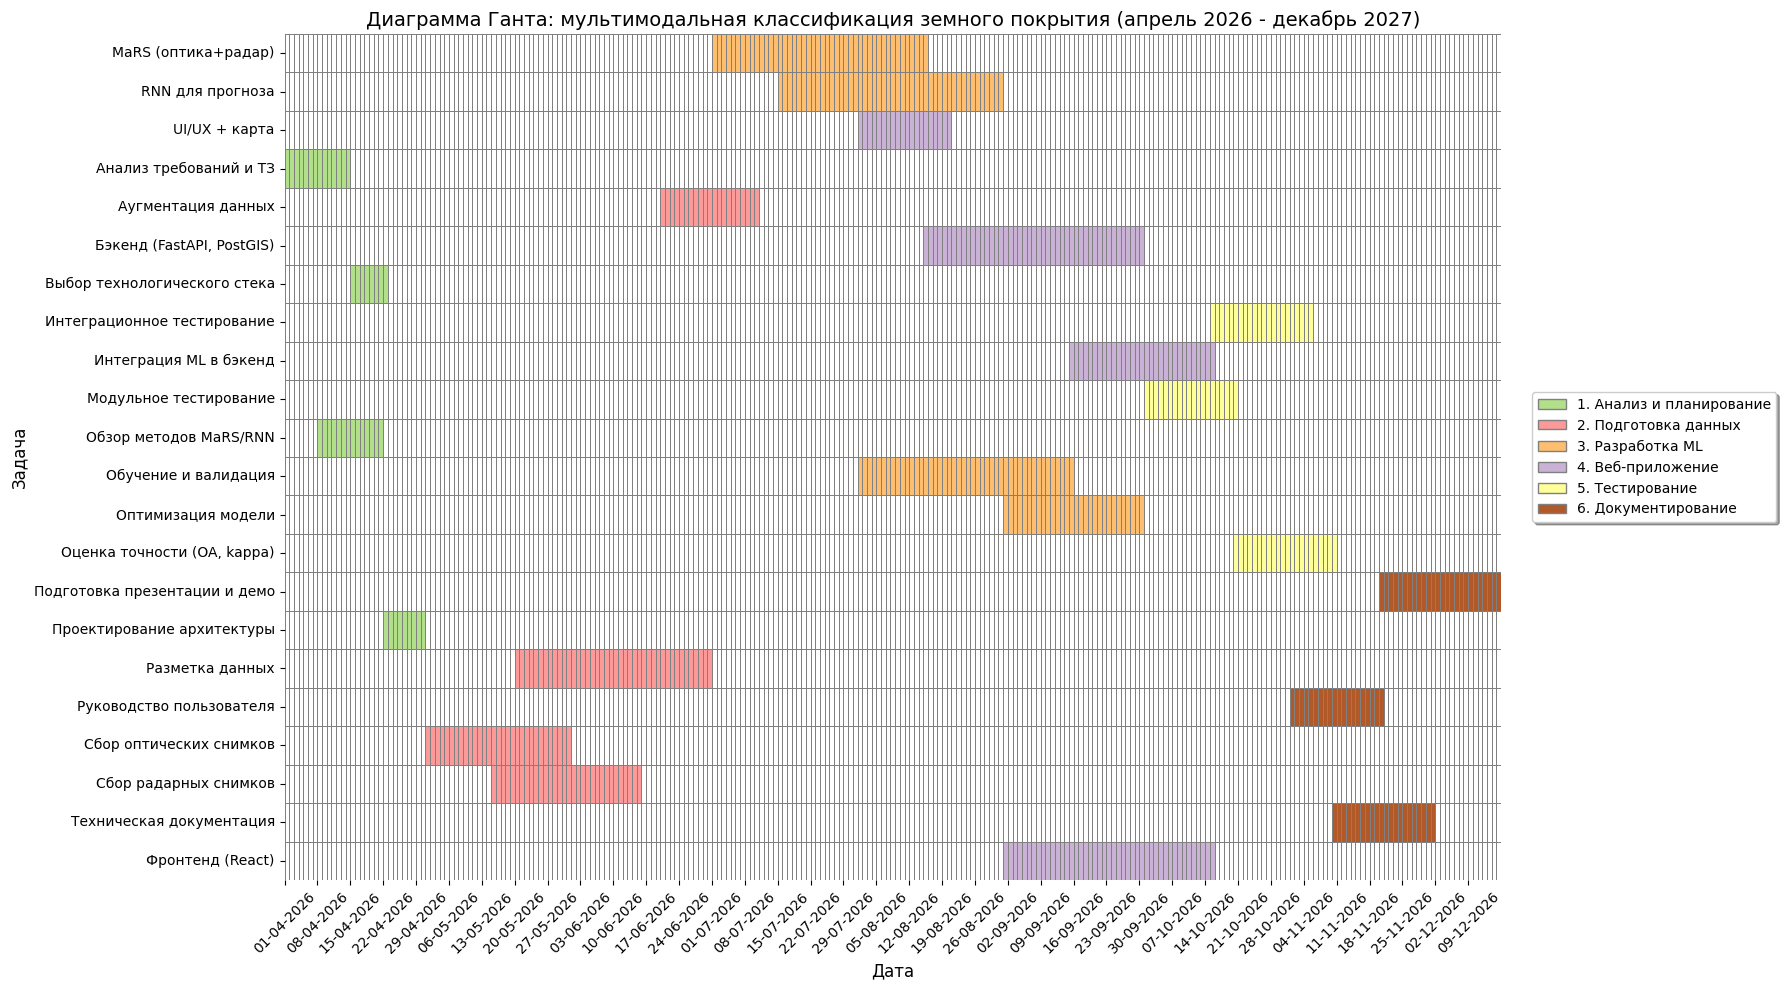

In [ ]:
# Список задач для проекта (апрель 2026 - июнь 2027)
sample_tasks = [
    # Этап 1: Анализ и планирование (апрель 2026)
    {"Task": "Анализ требований и ТЗ", "Start": "2026-04-01", "End": "2026-04-14", "Group": "1. Анализ и планирование"},
    {"Task": "Обзор методов MaRS/RNN", "Start": "2026-04-08", "End": "2026-04-21", "Group": "1. Анализ и планирование"},
    {"Task": "Выбор технологического стека", "Start": "2026-04-15", "End": "2026-04-22", "Group": "1. Анализ и планирование"},
    {"Task": "Проектирование архитектуры", "Start": "2026-04-22", "End": "2026-04-30", "Group": "1. Анализ и планирование"},

    # Этап 2: Подготовка данных (май - июль 2026)
    {"Task": "Сбор оптических снимков", "Start": "2026-05-01", "End": "2026-05-31", "Group": "2. Подготовка данных"},
    {"Task": "Сбор радарных снимков", "Start": "2026-05-15", "End": "2026-06-15", "Group": "2. Подготовка данных"},
    {"Task": "Разметка данных", "Start": "2026-05-20", "End": "2026-06-30", "Group": "2. Подготовка данных"},
    {"Task": "Аугментация данных", "Start": "2026-06-20", "End": "2026-07-10", "Group": "2. Подготовка данных"},

    # Этап 3: Разработка ML-моделей (июль - сентябрь 2026)
    {"Task": "MaRS (оптика+радар)", "Start": "2026-07-01", "End": "2026-08-15", "Group": "3. Разработка ML"},
    {"Task": "RNN для прогноза", "Start": "2026-07-15", "End": "2026-08-31", "Group": "3. Разработка ML"},
    {"Task": "Обучение и валидация", "Start": "2026-08-01", "End": "2026-09-15", "Group": "3. Разработка ML"},
    {"Task": "Оптимизация модели", "Start": "2026-09-01", "End": "2026-09-30", "Group": "3. Разработка ML"},

    # Этап 4: Веб-приложение (август - октябрь 2026)
    {"Task": "UI/UX + карта", "Start": "2026-08-01", "End": "2026-08-20", "Group": "4. Веб-приложение"},
    {"Task": "Бэкенд (FastAPI, PostGIS)", "Start": "2026-08-15", "End": "2026-09-30", "Group": "4. Веб-приложение"},
    {"Task": "Интеграция ML в бэкенд", "Start": "2026-09-15", "End": "2026-10-15", "Group": "4. Веб-приложение"},
    {"Task": "Фронтенд (React)", "Start": "2026-09-01", "End": "2026-10-15", "Group": "4. Веб-приложение"},

    # Этап 5: Тестирование (октябрь - ноябрь 2026)
    {"Task": "Модульное тестирование", "Start": "2026-10-01", "End": "2026-10-20", "Group": "5. Тестирование"},
    {"Task": "Интеграционное тестирование", "Start": "2026-10-15", "End": "2026-11-05", "Group": "5. Тестирование"},
    {"Task": "Оценка точности (OA, kappa)", "Start": "2026-10-20", "End": "2026-11-10", "Group": "5. Тестирование"},

    # Этап 6: Документирование (ноябрь - декабрь 2026)
    {"Task": "Руководство пользователя", "Start": "2026-11-01", "End": "2026-11-20", "Group": "6. Документирование"},
    {"Task": "Техническая документация", "Start": "2026-11-10", "End": "2026-12-01", "Group": "6. Документирование"},
    {"Task": "Подготовка презентации и демо", "Start": "2026-11-20", "End": "2026-12-15", "Group": "6. Документирование"},


]

# Вызов функции для создания диаграммы Ганта
create_gantt_chart(
    tasks=sample_tasks,
    title="Диаграмма Ганта: мультимодальная классификация земного покрытия (апрель 2026 - декабрь 2027)",
    save_path="gantt_chart_landcover.png",
    figsize=(18, 10)
)

#### **Задачи проекта:**

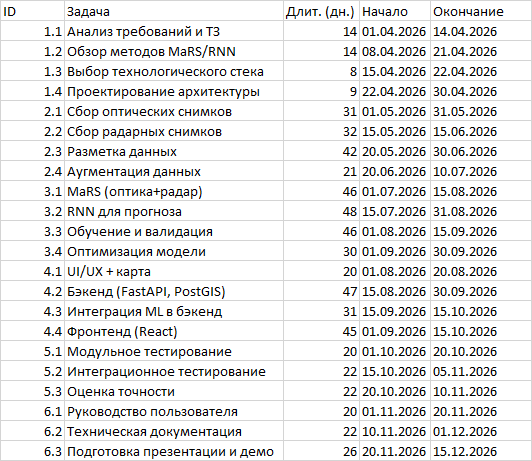

**Критический путь*:** 1.1 → 1.2 → 1.3 → 1.4 → 2.1 → 2.3 → 2.4 → 3.1 → 3.3 → 3.4 → 4.3 → 5.1 → 5.2 → 5.3 → 6.1/6.2 → 6.3

### **2. Анализ и управление рисками проекта**



#### **Таблица анализа рисков:**

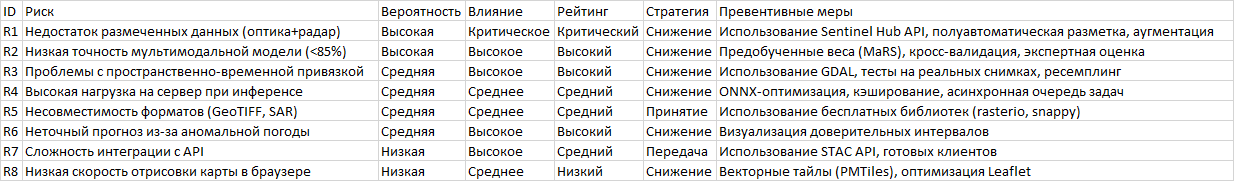

### **3. Контрольные точки проекта**


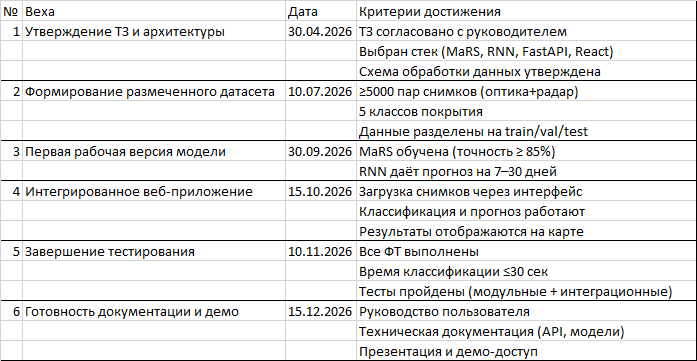

### **4. Пояснительная записка**



#### **Обоснование принятых решений**

Обоснование календарного плана
Проект разделён на 6 логических этапов, соответствующих диаграмме Ганта и спецификации требований к программному обеспечению. Ключевая особенность — параллельная работа над данными, ML-моделями и веб-приложением, что позволяет уложиться в 8,5 месяцев при полной загрузке.
Самый длительный критический путь начинается с анализа требований и заканчивается документацией, так как подготовка данных и обучение модели не могут быть сокращены без потери качества.

Методология анализа рисков
Использована качественная матрица «вероятность – влияние». Высшие приоритеты (R1, R2, R6) связаны с особенностями мультимодальных и прогностических моделей. Для каждого риска выбрана стратегия: снижение (технические меры) или передача (внешние API).

Связь компонентов
Диаграмма Ганта → риски → контрольные точки образуют замкнутую систему управления:

- Задачи с высоким риском (сбор данных, обучение) имеют буфер времени.

- Вехи привязаны к завершению критических задач (датасет, модель, интеграция).

- Критерии вех проверяют снижение ключевых рисков (точность, время отклика).